In [2]:
import nltk
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from scipy.stats import f_oneway, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import scipy.stats as stats
from scipy.stats import ttest_ind
import re

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# SECTION — Data Loading

# --- Product Information ---
df_product = pd.read_csv('/content/drive/MyDrive/archive (3)/product_info.csv', low_memory=False)

# --- Review Files ---
df_r1 = pd.read_csv('/content/drive/MyDrive/archive (3)/reviews_0-250.csv', low_memory=False)
df_r2 = pd.read_csv('/content/drive/MyDrive/archive (3)/reviews_250-500.csv', low_memory=False)
df_r3 = pd.read_csv('/content/drive/MyDrive/archive (3)/reviews_500-750.csv', low_memory=False)
df_r4 = pd.read_csv('/content/drive/MyDrive/archive (3)/reviews_750-1250.csv', low_memory=False)
df_r5 = pd.read_csv('/content/drive/MyDrive/archive (3)/reviews_1250-end.csv', low_memory=False)

print(f"Product records: {df_product.shape}")
print(f"Review files loaded: 5 files")
print(f"Review rows (each file): {df_r1.shape[0]}, {df_r2.shape[0]}, {df_r3.shape[0]}, {df_r4.shape[0]}, {df_r5.shape[0]}")

Product records: (8494, 27)
Review files loaded: 5 files
Review rows (each file): 602130, 206725, 116262, 119317, 49977


In [5]:
# SECTION — Merging
# Columns from product_info to bring into the merged dataset
product_cols = [
    'product_id', 'brand_id', 'loves_count', 'reviews', 'size',
    'variation_type', 'variation_value', 'ingredients',
    'limited_edition', 'new', 'online_only', 'out_of_stock',
    'sephora_exclusive', 'highlights', 'primary_category',
    'secondary_category', 'tertiary_category', 'child_count'
]

# Concatenate all review files
df_concat = pd.concat([df_r1, df_r2, df_r3, df_r4, df_r5], axis=0, ignore_index=True)

# Left merge: every review gets enriched with product attributes
df_merged = pd.merge(df_concat, df_product[product_cols], on='product_id', how='left')

print(f"Merged DataFrame shape: {df_merged.shape}")
print(f"Total reviews: {len(df_merged):,}")

Merged DataFrame shape: (1094411, 36)
Total reviews: 1,094,411


In [6]:
# SECTION — Data Cleaning
# Step 1: Drop columns with high null ratios
high_null_cols = ['Unnamed: 0', 'variation_desc', 'value_price_usd',
                  'sale_price_usd', 'child_max_price', 'child_min_price']
df_merged.drop(columns=[c for c in high_null_cols if c in df_merged.columns], inplace=True)
print(f"After dropping high-null columns: {df_merged.shape}")

# Step 2: Remove rows with >= 12 null values
mask_rows = df_merged.isnull().sum(axis=1) >= 12
df_merged.drop(index=df_merged[mask_rows].index, inplace=True)
print(f"After removing high-null rows: {df_merged.shape}")

# Step 3: Impute missing values
df_merged['is_recommended'].fillna(0, inplace=True)
df_merged['helpfulness'].fillna(df_merged['helpfulness'].median(), inplace=True)
df_merged['review_text'].fillna('No Review', inplace=True)
df_merged['review_title'].fillna('No Title', inplace=True)
for col in ['skin_tone', 'eye_color', 'skin_type', 'hair_color']:
    df_merged[col].fillna('Unknown', inplace=True)
df_merged['tertiary_category'].fillna('Unspecified', inplace=True)
df_merged['highlights'].fillna('None', inplace=True)
df_merged['ingredients'].fillna('Not Listed', inplace=True)
df_merged['size'].fillna('Not Specified', inplace=True)

# Step 4: Cap price outliers
df_merged['price_usd'] = np.clip(df_merged['price_usd'], 0, 500)

# Step 5: Remove duplicates
df_merged.drop_duplicates(inplace=True)

# Step 6: Parse dates and extract year
df_merged['submission_time'] = pd.to_datetime(df_merged['submission_time'], errors='coerce')
df_merged['submission_year'] = df_merged['submission_time'].dt.year

# Step 7: Sentiment label from review rating
def label_sentiment(r):
    if r >= 4:
        return 'Positive'
    elif r == 3:
        return 'Neutral'
    else:
        return 'Negative'

df_merged['sentiment_label'] = df_merged['rating'].apply(label_sentiment)

# Step 8: Price tier
df_merged['price_tier'] = pd.cut(
    df_merged['price_usd'],
    bins=[0, 20, 50, 100, 500],
    labels=['Budget (<$20)', 'Mid-Range ($20-50)', 'Premium ($50-100)', 'Luxury (>$100)']
)

print(f"\nFinal clean DataFrame shape: {df_merged.shape}")
print(f"Columns: {df_merged.columns.tolist()}")

After dropping high-null columns: (1094411, 35)
After removing high-null rows: (1094404, 35)

Final clean DataFrame shape: (1094180, 38)
Columns: ['author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd', 'brand_id', 'loves_count', 'reviews', 'size', 'variation_type', 'variation_value', 'ingredients', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'submission_year', 'sentiment_label', 'price_tier']


In [7]:
# Missing Value Summary Post-Cleaning
missing_summary = pd.DataFrame({
    'Missing Count': df_merged.isnull().sum(),
    'Missing %': (df_merged.isnull().sum() / len(df_merged) * 100).round(2)
})
print(missing_summary[missing_summary['Missing Count'] > 0])

                 Missing Count  Missing %
variation_type           51445        4.7
variation_value          63422        5.8


In [8]:
# SECTION — Descriptive Statistics for Numeric Variables

numeric_vars = ['rating', 'price_usd', 'loves_count', 'helpfulness',
                'total_feedback_count', 'total_pos_feedback_count',
                'total_neg_feedback_count', 'reviews', 'child_count']

desc = df_merged[numeric_vars].describe(percentiles=[0.25, 0.50, 0.75]).T

# Add skewness and kurtosis
desc['skewness'] = df_merged[numeric_vars].skew()
desc['kurtosis'] = df_merged[numeric_vars].kurt()

desc = desc.rename(columns={
    'count': 'N', 'mean': 'Mean', 'std': 'Std Dev',
    'min': 'Min', '25%': 'Q1', '50%': 'Median',
    '75%': 'Q3', 'max': 'Max'
})

print("=" * 80)
print("TABLE: Descriptive Statistics of Key Numerical Variables")
print("=" * 80)
print(desc.round(3).to_string())
print("\nNote: N = valid non-null count; Skewness > 0 = right-skewed; Kurtosis > 3 = leptokurtic")

TABLE: Descriptive Statistics of Key Numerical Variables
                                  N        Mean     Std Dev  Min         Q1     Median          Q3        Max  skewness   kurtosis
rating                    1094180.0       4.299       1.149  1.0      4.000      5.000       5.000        5.0    -1.677      1.783
price_usd                 1094180.0      49.004      39.897  3.0     25.000     39.000      62.000      500.0     3.668     22.906
loves_count               1094180.0  106854.875  167688.490  0.0  16656.000  48796.000  123439.000  1081315.0     3.656     16.365
helpfulness               1094180.0       0.850       0.235  0.0      0.929      0.929       0.929        1.0    -2.529      5.718
total_feedback_count      1094180.0       4.178      22.718  0.0      0.000      0.000       3.000     5464.0    68.376   9780.782
total_pos_feedback_count  1094180.0       3.283      19.677  0.0      0.000      0.000       3.000     5050.0    78.277  12537.824
total_neg_feedback_count  

In [31]:
# SECTION — Frequency Distribution of Categorical Variables

print("TABLE: Frequency Distribution — Skin Type")
print(df_merged['skin_type'].value_counts().to_frame('Count').assign(
    Percentage=lambda x: (x['Count'] / x['Count'].sum() * 100).round(2)
).to_string())

print("\nTABLE: Frequency Distribution — Sentiment Label")
print(df_merged['sentiment_label'].value_counts().to_frame('Count').assign(
    Percentage=lambda x: (x['Count'] / x['Count'].sum() * 100).round(2)
).to_string())

print("\nTABLE: Frequency Distribution — Primary Category")
print(df_merged['primary_category'].value_counts().head(10).to_frame('Count').assign(
    Percentage=lambda x: (x['Count'] / x['Count'].sum() * 100).round(2)
).to_string())

print("\nTABLE: Frequency Distribution — Rating")
print(df_merged['rating'].value_counts().sort_index().to_frame('Count').assign(
    Percentage=lambda x: (x['Count'] / x['Count'].sum() * 100).round(2)
).to_string())

TABLE: Frequency Distribution — Skin Type
              Count  Percentage
skin_type                      
combination  544447       49.76
dry          185913       16.99
normal       131897       12.05
oily         120481       11.01
Unknown      111442       10.18

TABLE: Frequency Distribution — Sentiment Label
                  Count  Percentage
sentiment_label                    
Positive         898125       82.08
Negative         114242       10.44
Neutral           81813        7.48

TABLE: Frequency Distribution — Primary Category
                    Count  Percentage
primary_category                     
Skincare          1094180       100.0

TABLE: Frequency Distribution — Rating
         Count  Percentage
rating                    
1        61217        5.59
2        53025        4.85
3        81813        7.48
4       199360       18.22
5       698765       63.86


In [10]:
# SECTION — Product-Level Descriptive Statistics

prod_desc = df_product[['rating', 'price_usd', 'loves_count', 'reviews']].describe(
    percentiles=[0.25, 0.50, 0.75]
).T
prod_desc['skewness'] = df_product[['rating', 'price_usd', 'loves_count', 'reviews']].skew()
prod_desc['kurtosis'] = df_product[['rating', 'price_usd', 'loves_count', 'reviews']].kurt()

print("TABLE: Descriptive Statistics — Product-Level Variables")
print(prod_desc.round(3).to_string())

TABLE: Descriptive Statistics — Product-Level Variables
              count       mean        std  min       25%       50%        75%        max  skewness  kurtosis
rating       8216.0      4.195      0.517  1.0     3.982     4.289      4.531        5.0    -1.518     4.325
price_usd    8494.0     51.656     53.669  3.0    25.000    35.000     58.000     1900.0     7.380   175.726
loves_count  8494.0  29179.566  66092.123  0.0  3758.000  9880.000  26841.250  1401068.0     7.253    81.971
reviews      8216.0    448.546   1101.983  1.0    26.000   122.000    418.000    21281.0     7.878    92.016


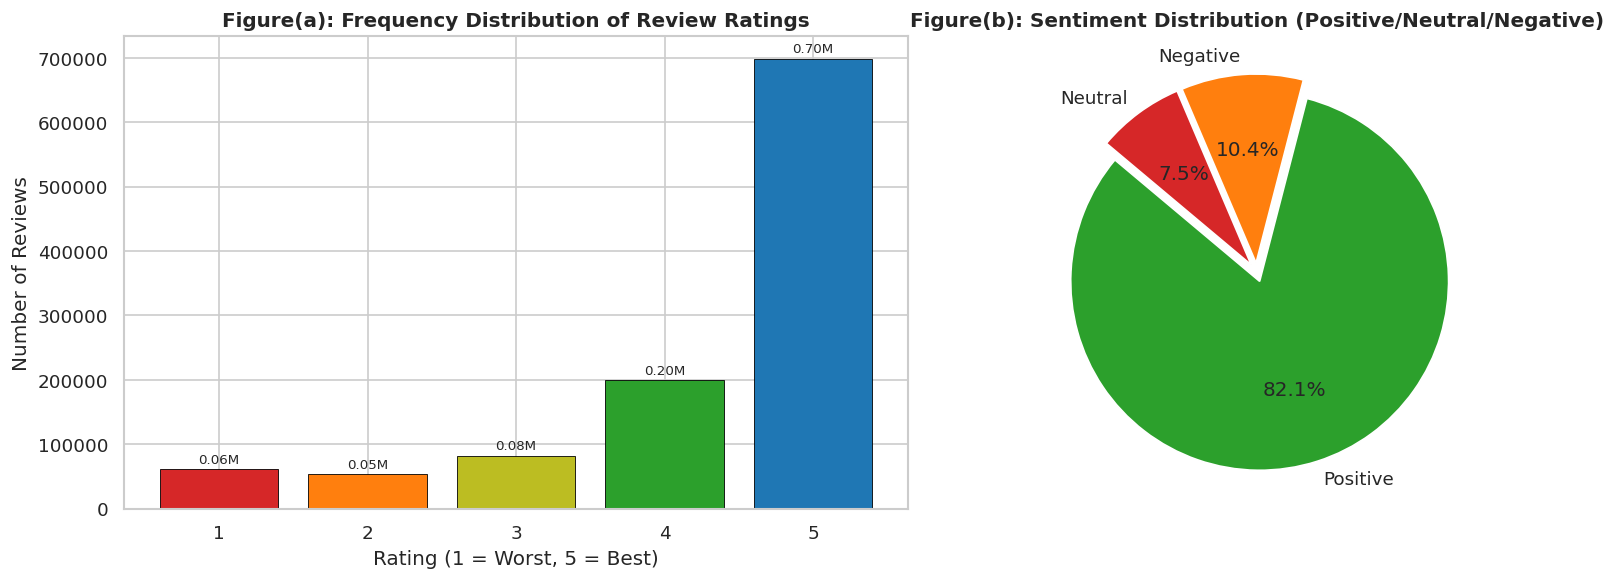

Interpretation: The rating distribution is heavily left-skewed (most reviews are 5-star), indicating a positivity bias common in beauty product reviews.


In [11]:
# FIGURE — Distribution of Review Ratings

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
rating_counts = df_merged['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#d62728','#ff7f0e','#bcbd22','#2ca02c','#1f77b4'],
            edgecolor='black', linewidth=0.5)
axes[0].set_title('Figure(a): Frequency Distribution of Review Ratings', fontweight='bold')
axes[0].set_xlabel('Rating (1 = Worst, 5 = Best)')
axes[0].set_ylabel('Number of Reviews')
for bar, count in zip(axes[0].patches, rating_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{count/1e6:.2f}M', ha='center', va='bottom', fontsize=8)

# Pie chart of sentiment
sentiment_counts = df_merged['sentiment_label'].value_counts()
axes[1].pie(sentiment_counts, labels=sentiment_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=['#2ca02c','#ff7f0e','#d62728'],
            explode=[0.05, 0.05, 0.05])
axes[1].set_title('Figure(b): Sentiment Distribution (Positive/Neutral/Negative)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_1_rating_distribution.png', bbox_inches='tight')
plt.show()
print("Interpretation: The rating distribution is heavily left-skewed (most reviews are 5-star),"
      " indicating a positivity bias common in beauty product reviews.")

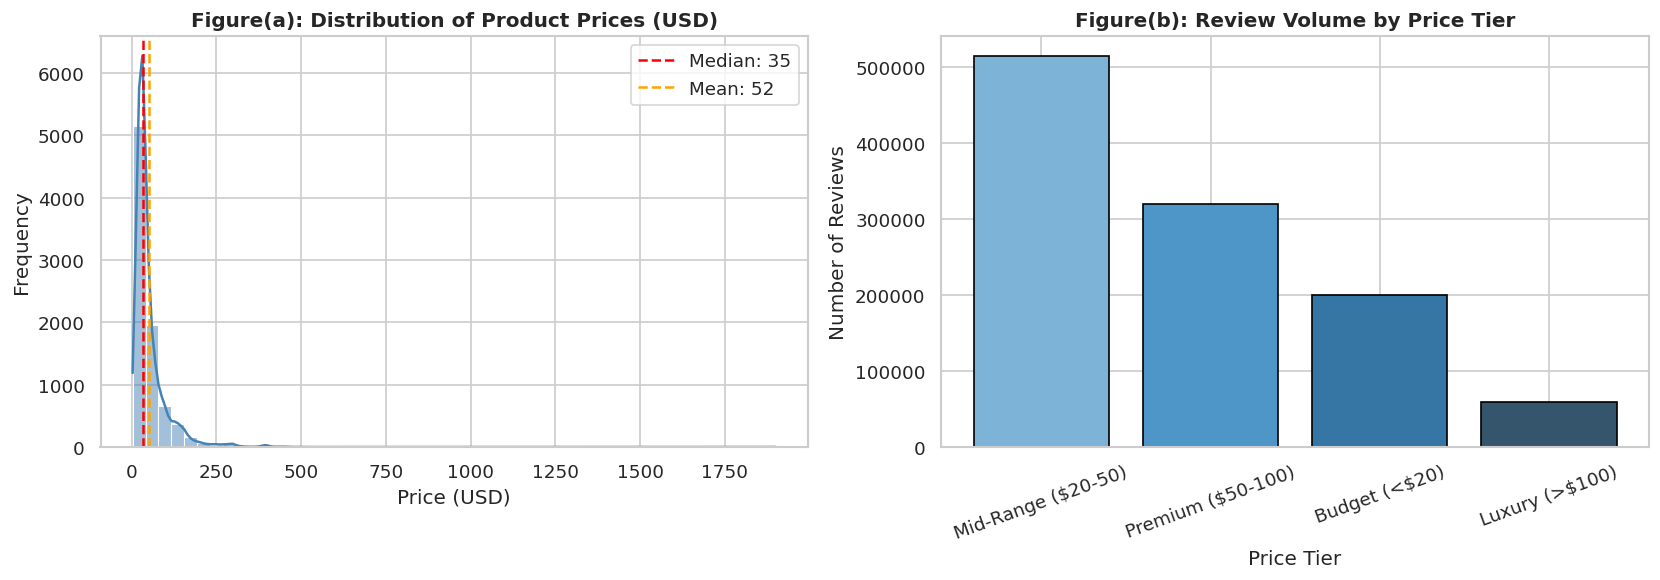

Interpretation: Prices are right-skewed, with the majority of products priced under $100. The mid-range tier (20–50) generates the highest review volume.


In [12]:
# FIGURE — Price Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_product['price_usd'].dropna(), bins=50,
             kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Figure(a): Distribution of Product Prices (USD)', fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_product['price_usd'].median(), color='red',
                linestyle='--', label=f"Median: {df_product['price_usd'].median():.0f}")
axes[0].axvline(df_product['price_usd'].mean(), color='orange',
                linestyle='--', label=f"Mean: {df_product['price_usd'].mean():.0f}")
axes[0].legend()

# Box plot by price tier
price_tier_counts = df_merged['price_tier'].value_counts()
axes[1].bar(price_tier_counts.index.astype(str), price_tier_counts.values,
            color=sns.color_palette('Blues_d', 4), edgecolor='black')
axes[1].set_title('Figure(b): Review Volume by Price Tier', fontweight='bold')
axes[1].set_xlabel('Price Tier')
axes[1].set_ylabel('Number of Reviews')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig6_2_price_distribution.png', bbox_inches='tight')
plt.show()
print("Interpretation: Prices are right-skewed, with the majority of products priced under $100."
      " The mid-range tier (20–50) generates the highest review volume.")

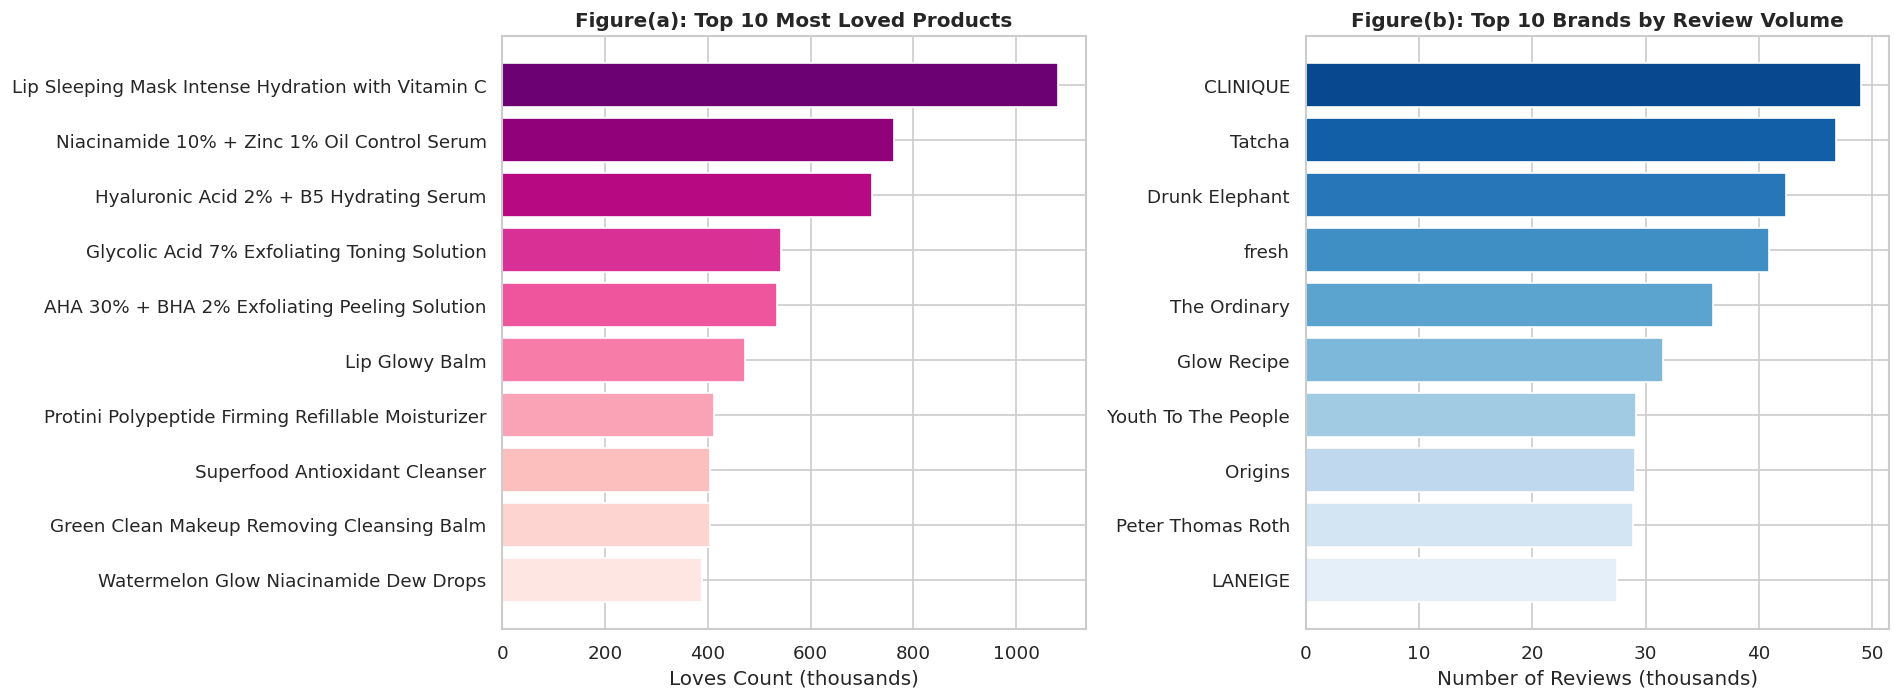

In [13]:
# FIGURE — Most Loved Products and Best-Selling Brands

# Top 10 products by loves_count
top_loved = (df_merged
             .groupby('product_name')['loves_count']
             .max()
             .nlargest(10)
             .reset_index())

# Top 10 brands by review volume (SAFE)
if 'brand_name' in df_merged.columns:
    top_brands = (df_merged['brand_name']
                  .value_counts()
                  .head(10)
                  .reset_index())
    top_brands.columns = ['brand_name', 'review_count']
else:
    raise ValueError("brand_name column not found — check dataset")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Most Loved Products
axes[0].barh(top_loved['product_name'], top_loved['loves_count'] / 1e3,
             color=sns.color_palette('RdPu', 10)[::-1])
axes[0].set_xlabel('Loves Count (thousands)')
axes[0].set_title('Figure(a): Top 10 Most Loved Products', fontweight='bold')
axes[0].invert_yaxis()

# Most Reviewed Brands
axes[1].barh(top_brands['brand_name'], top_brands['review_count'] / 1e3,
             color=sns.color_palette('Blues', 10)[::-1])
axes[1].set_xlabel('Number of Reviews (thousands)')
axes[1].set_title('Figure(b): Top 10 Brands by Review Volume', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('fig6_3_loved_brands.png', bbox_inches='tight')
plt.show()

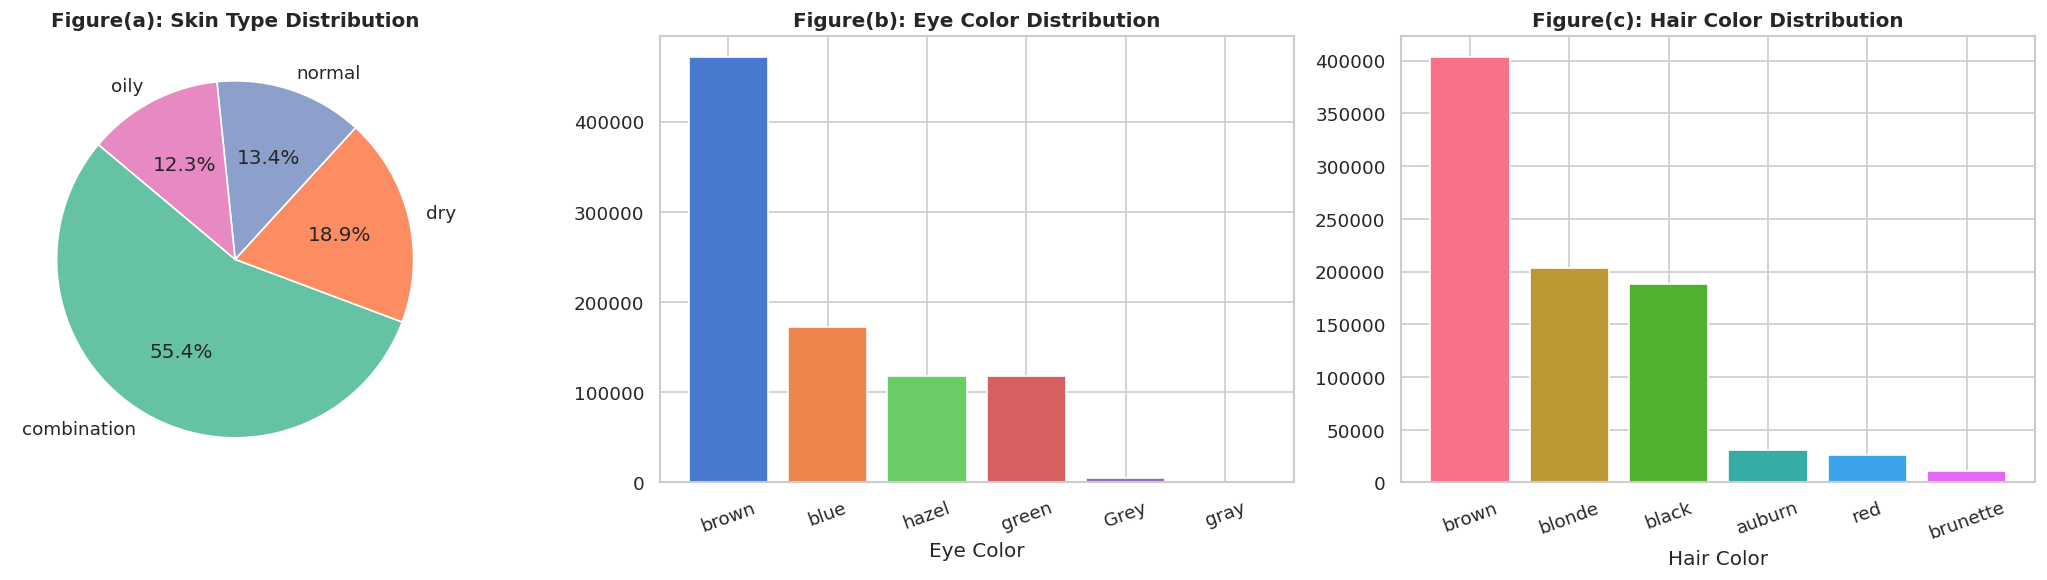

Interpretation: Combination skin is the most prevalent skin type among reviewers, followed by Oily. Brown hair and Hazel/Brown eyes are most common.


In [14]:
# FIGURE — Skin Type and Eye/Hair Color Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

skin_type_counts = df_merged[df_merged['skin_type'] != 'Unknown']['skin_type'].value_counts()
axes[0].pie(skin_type_counts, labels=skin_type_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(skin_type_counts)))
axes[0].set_title('Figure(a): Skin Type Distribution', fontweight='bold')

eye_counts = df_merged[df_merged['eye_color'] != 'Unknown']['eye_color'].value_counts().head(6)
axes[1].bar(eye_counts.index, eye_counts.values,
            color=sns.color_palette('muted', len(eye_counts)))
axes[1].set_title('Figure(b): Eye Color Distribution', fontweight='bold')
axes[1].set_xlabel('Eye Color')
axes[1].tick_params(axis='x', rotation=20)

hair_counts = df_merged[df_merged['hair_color'] != 'Unknown']['hair_color'].value_counts().head(6)
axes[2].bar(hair_counts.index, hair_counts.values,
            color=sns.color_palette('husl', len(hair_counts)))
axes[2].set_title('Figure(c): Hair Color Distribution', fontweight='bold')
axes[2].set_xlabel('Hair Color')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig6_4_reviewer_demographics.png', bbox_inches='tight')
plt.show()
print("Interpretation: Combination skin is the most prevalent skin type among reviewers,"
      " followed by Oily. Brown hair and Hazel/Brown eyes are most common.")

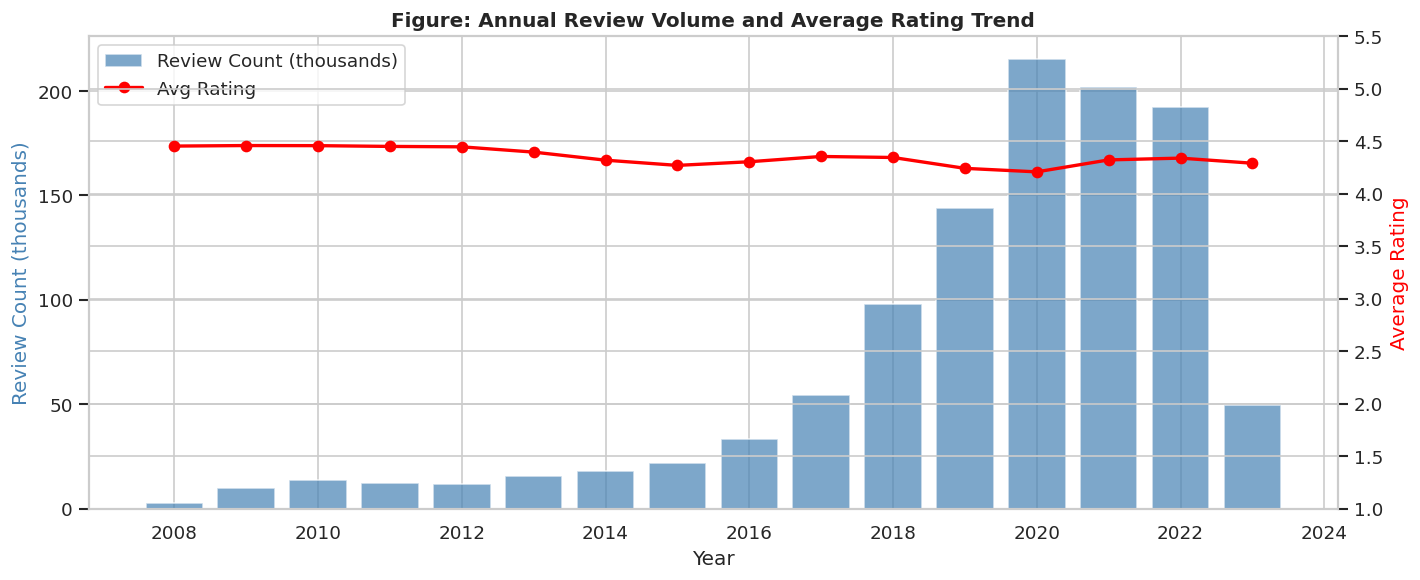

In [15]:
# FIGURE — Time Trend: Review Volume by Year

yearly = (df_merged
          .groupby('submission_year')
          .agg(review_count=('rating', 'count'),
               avg_rating=('rating', 'mean'))
          .reset_index()
          .dropna())

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(yearly['submission_year'].astype(int),
        yearly['review_count'] / 1e3,
        color='steelblue', alpha=0.7, label='Review Count (thousands)')
ax2.plot(yearly['submission_year'].astype(int),
         yearly['avg_rating'],
         color='red', marker='o', linewidth=2, label='Avg Rating')

ax1.set_xlabel('Year')
ax1.set_ylabel('Review Count (thousands)', color='steelblue')
ax2.set_ylabel('Average Rating', color='red')
ax2.set_ylim(1, 5.5)
ax1.set_title('Figure: Annual Review Volume and Average Rating Trend', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('fig6_7_time_trend.png', bbox_inches='tight')
plt.show()

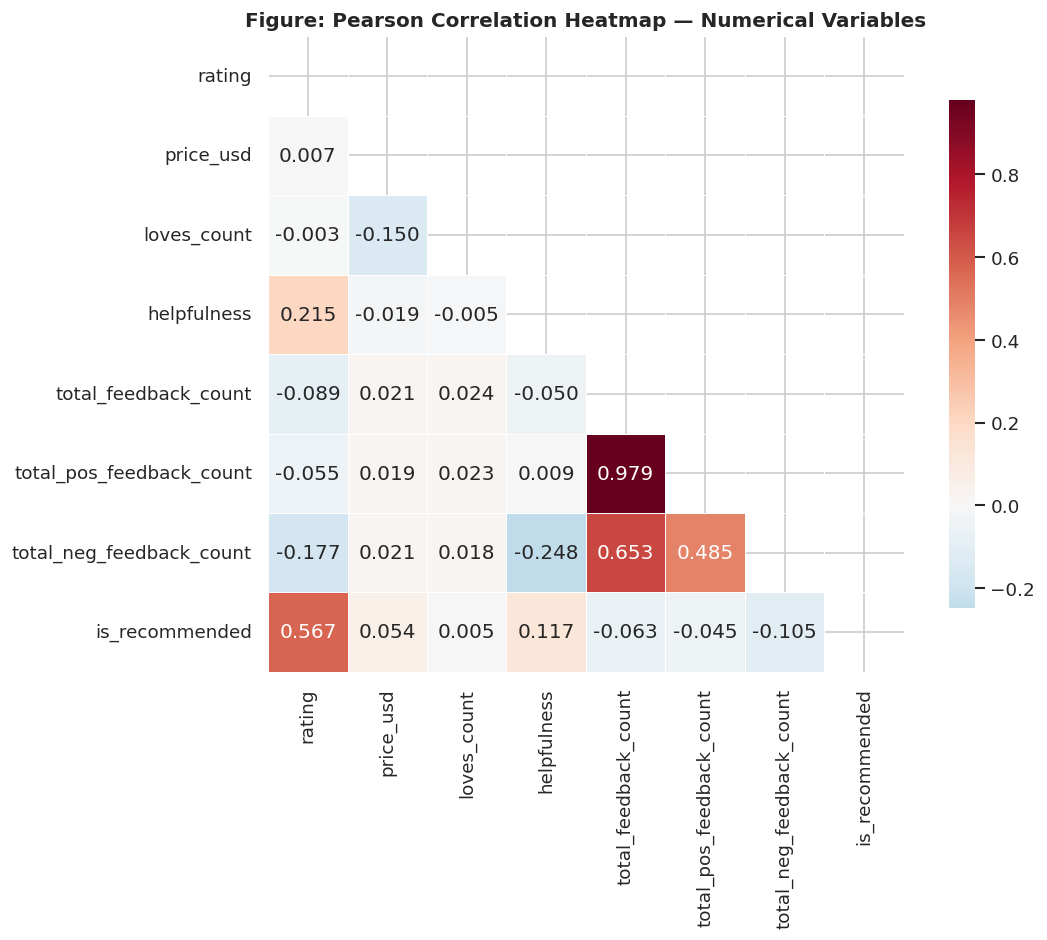


TABLE: Full Correlation Matrix
                          rating  price_usd  loves_count  helpfulness  total_feedback_count  total_pos_feedback_count  total_neg_feedback_count  is_recommended
rating                    1.0000     0.0072      -0.0032       0.2149               -0.0886                   -0.0548                   -0.1766          0.5675
price_usd                 0.0072     1.0000      -0.1499      -0.0189                0.0215                    0.0191                    0.0211          0.0543
loves_count              -0.0032    -0.1499       1.0000      -0.0046                0.0238                    0.0227                    0.0179          0.0050
helpfulness               0.2149    -0.0189      -0.0046       1.0000               -0.0504                    0.0085                   -0.2483          0.1167
total_feedback_count     -0.0886     0.0215       0.0238      -0.0504                1.0000                    0.9790                    0.6528         -0.0629
total_po

In [16]:
# FIGURE — Correlation Heatmap

corr_vars = ['rating', 'price_usd', 'loves_count', 'helpfulness',
             'total_feedback_count', 'total_pos_feedback_count',
             'total_neg_feedback_count', 'is_recommended']

corr_matrix = df_merged[corr_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Figure: Pearson Correlation Heatmap — Numerical Variables', fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_8_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\nTABLE: Full Correlation Matrix")
print(corr_matrix.round(4).to_string())
print("\nInterpretation: Rating and is_recommended show the strongest positive correlation,"
      " confirming internal consistency. Price shows negligible correlation with rating.")

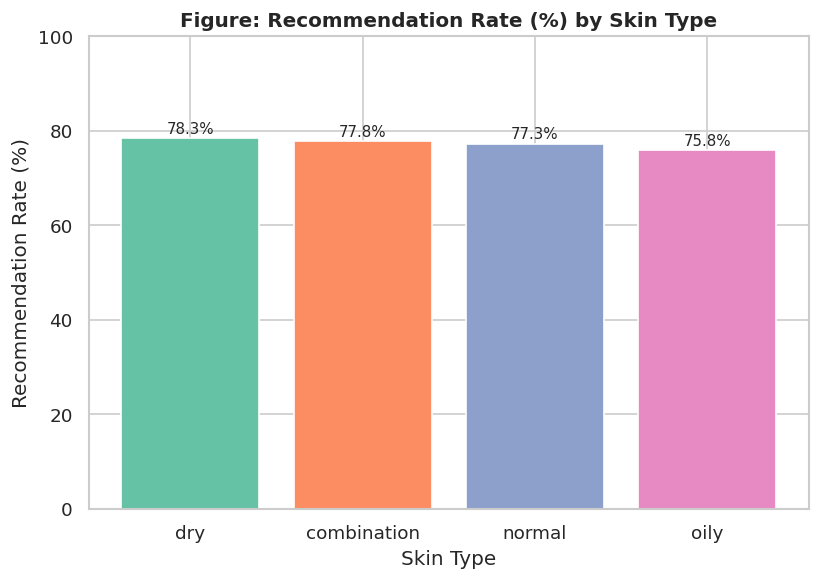

In [17]:
# FIGURE — Recommendation Rate by Skin Type

plt.figure(figsize=(7, 5))

rec_rate = (df_merged[df_merged['skin_type'] != 'Unknown']
            .groupby('skin_type')['is_recommended']
            .mean()
            .sort_values(ascending=False))

plt.bar(rec_rate.index, rec_rate.values * 100,
        color=sns.color_palette('Set2', len(rec_rate)))

plt.title('Figure: Recommendation Rate (%) by Skin Type', fontweight='bold')
plt.xlabel('Skin Type')
plt.ylabel('Recommendation Rate (%)')
plt.ylim(0, 100)

for i, (k, v) in enumerate(rec_rate.items()):
    plt.text(i, v * 100 + 0.5, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig6_9_recommendation.png', bbox_inches='tight')
plt.show()

In [18]:
# HYPOTHESIS 1 — Chi-Square Test: Skin Type vs Is_Recommended

print("HYPOTHESIS TEST 1: Chi-Square Test of Independence")
print("Variables: skin_type  ×  is_recommended")

df_h1 = df_merged[df_merged['skin_type'] != 'Unknown'].copy()
df_h1['is_recommended'] = df_h1['is_recommended'].astype(int)

contingency_table = pd.crosstab(df_h1['skin_type'], df_h1['is_recommended'])
contingency_table.columns = ['Not Recommended', 'Recommended']

print("\nContingency Table:")
print(contingency_table.to_string())

chi2, p_val, dof, expected = chi2_contingency(contingency_table)
cramers_v = np.sqrt(chi2 / (len(df_h1) * (min(contingency_table.shape) - 1)))

print(f"\nChi-Square Statistic (χ²): {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_val:.6f}")
print(f"Cramér's V (Effect Size): {cramers_v:.4f}")
print()
if p_val < 0.05:
    print("DECISION: Reject H₀ at α = 0.05")
    print("CONCLUSION: Skin type is significantly associated with recommendation behavior.")
    print(f"Effect size (Cramér's V = {cramers_v:.4f}) indicates a {'weak' if cramers_v < 0.1 else 'moderate' if cramers_v < 0.3 else 'strong'} association.")
else:
    print("DECISION: Fail to Reject H₀ at α = 0.05")
    print("CONCLUSION: No significant association found between skin type and recommendation.")

HYPOTHESIS TEST 1: Chi-Square Test of Independence
Variables: skin_type  ×  is_recommended

Contingency Table:
             Not Recommended  Recommended
skin_type                                
combination           120941       423506
dry                    40258       145655
normal                 29971       101926
oily                   29104        91377

Chi-Square Statistic (χ²): 291.8955
Degrees of Freedom: 3
P-value: 0.000000
Cramér's V (Effect Size): 0.0172

DECISION: Reject H₀ at α = 0.05
CONCLUSION: Skin type is significantly associated with recommendation behavior.
Effect size (Cramér's V = 0.0172) indicates a weak association.


In [19]:
# HYPOTHESIS 2 — Independent Samples t-Test: Limited Edition vs Standard Product Prices

print("HYPOTHESIS TEST 2: Independent Samples t-Test")
print("Variable: price_usd | Groups: limited_edition (1 vs 0)")

limited = df_product[df_product['limited_edition'] == 1]['price_usd'].dropna()
standard = df_product[df_product['limited_edition'] == 0]['price_usd'].dropna()

# Levene's test for equality of variances
lev_stat, lev_p = stats.levene(limited, standard)
print(f"\nLevene's Test for Equality of Variances:")
print(f"  F = {lev_stat:.4f}, p = {lev_p:.4f}")
equal_var = lev_p > 0.05

t_stat, p_val_t = ttest_ind(limited, standard, equal_var=equal_var)

# Cohen's d
pooled_std = np.sqrt((limited.std()**2 + standard.std()**2) / 2)
cohens_d = (limited.mean() - standard.mean()) / pooled_std

print(f"\nLimited Edition (n={len(limited)}): Mean = ${limited.mean():.2f}, SD = ${limited.std():.2f}")
print(f"Standard Products (n={len(standard)}): Mean = ${standard.mean():.2f}, SD = ${standard.std():.2f}")
print(f"\nt-Statistic: {t_stat:.4f}")
print(f"P-value (two-tailed): {p_val_t:.6f}")
print(f"Cohen's d (Effect Size): {cohens_d:.4f}")

print()
if p_val_t < 0.05:
    print("DECISION: Reject H₀ at α = 0.05")
    print(f"CONCLUSION: Limited edition products are significantly {'more' if limited.mean() > standard.mean() else 'less'} expensive.")
else:
    print("DECISION: Fail to Reject H₀ — No significant price difference.")

HYPOTHESIS TEST 2: Independent Samples t-Test
Variable: price_usd | Groups: limited_edition (1 vs 0)

Levene's Test for Equality of Variances:
  F = 7.6917, p = 0.0056

Limited Edition (n=597): Mean = $60.70, SD = $56.49
Standard Products (n=7897): Mean = $50.97, SD = $53.39

t-Statistic: 4.0729
P-value (two-tailed): 0.000052
Cohen's d (Effect Size): 0.1770

DECISION: Reject H₀ at α = 0.05
CONCLUSION: Limited edition products are significantly more expensive.


HYPOTHESIS TEST 3: Pearson Correlation
Variables: price_usd × loves_count

N = 8,494
Pearson's r = -0.0896
P-value = 0.000000
r² (Coefficient of Determination) = 0.0080


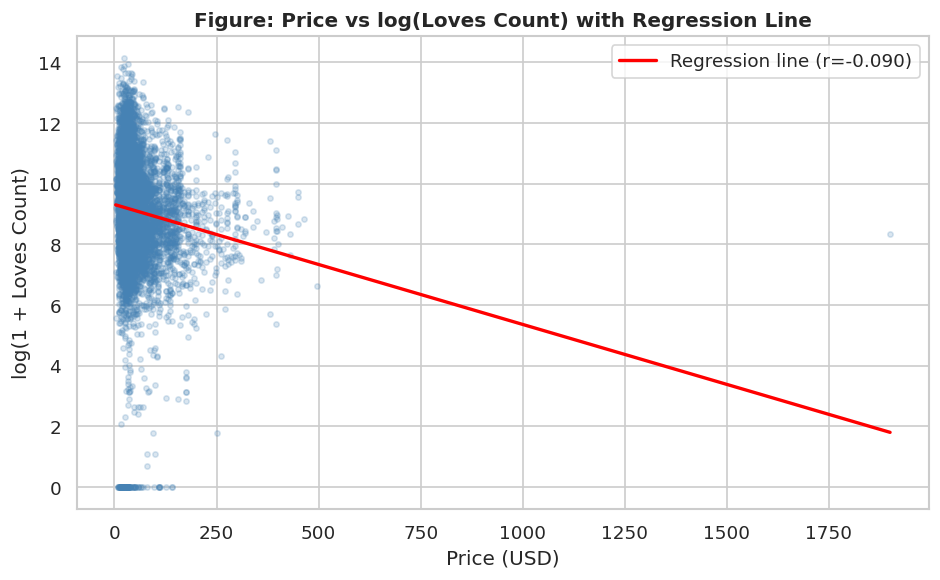


DECISION: Reject H₀ — Significant correlation exists.
CONCLUSION: Price and loves_count are negatively correlated (r=-0.090), though the relationship is weak.


In [20]:
# HYPOTHESIS 3 — Pearson Correlation: Price vs Loves Count

print("HYPOTHESIS TEST 3: Pearson Correlation")
print("Variables: price_usd × loves_count")

prod_clean = df_product[['price_usd', 'loves_count']].dropna()
r, p_corr = pearsonr(prod_clean['price_usd'], prod_clean['loves_count'])

print(f"\nN = {len(prod_clean):,}")
print(f"Pearson's r = {r:.4f}")
print(f"P-value = {p_corr:.6f}")
print(f"r² (Coefficient of Determination) = {r**2:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(prod_clean['price_usd'], np.log1p(prod_clean['loves_count']),
           alpha=0.2, s=10, color='steelblue')
m, b = np.polyfit(prod_clean['price_usd'], np.log1p(prod_clean['loves_count']), 1)
x_line = np.linspace(prod_clean['price_usd'].min(), prod_clean['price_usd'].max(), 200)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2,
        label=f'Regression line (r={r:.3f})')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('log(1 + Loves Count)')
ax.set_title('Figure: Price vs log(Loves Count) with Regression Line', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_7_1_corr_price_loves.png', bbox_inches='tight')
plt.show()

print()
if p_corr < 0.05:
    print("DECISION: Reject H₀ — Significant correlation exists.")
    print(f"CONCLUSION: Price and loves_count are {'positively' if r > 0 else 'negatively'} correlated (r={r:.3f}), though the relationship is {'weak' if abs(r) < 0.3 else 'moderate'}.")
else:
    print("DECISION: Fail to Reject H₀ — No significant correlation.")

In [21]:
# HYPOTHESIS 4 — Chi-Square: Sephora Exclusive × Rating Tier

print("HYPOTHESIS TEST 4: Chi-Square Test")
print("Variables: sephora_exclusive × Rating Tier")

df_product['rating_tier'] = pd.cut(
    df_product['rating'],
    bins=[0, 3.5, 4.2, 5.0],
    labels=['Low (≤3.5)', 'Medium (3.5–4.2)', 'High (>4.2)']
)

ct2 = pd.crosstab(df_product['sephora_exclusive'], df_product['rating_tier'])
ct2.index = ['Non-Exclusive', 'Sephora Exclusive']
print("\nContingency Table:")
print(ct2.to_string())

chi2_5, p5, dof5, exp5 = chi2_contingency(ct2)
v5 = np.sqrt(chi2_5 / (df_product.dropna(subset=['rating_tier']).shape[0] * (min(ct2.shape) - 1)))

print(f"\nχ² = {chi2_5:.4f}, df = {dof5}, p = {p5:.6f}")
print(f"Cramér's V = {v5:.4f}")

if p5 < 0.05:
    print("DECISION: Reject H₀")
    print("CONCLUSION: Sephora Exclusive products have a significantly different rating distribution.")
else:
    print("DECISION: Fail to Reject H₀")

HYPOTHESIS TEST 4: Chi-Square Test
Variables: sephora_exclusive × Rating Tier

Contingency Table:
rating_tier        Low (≤3.5)  Medium (3.5–4.2)  High (>4.2)
Non-Exclusive             590              1919         3397
Sephora Exclusive         211               727         1372

χ² = 2.7909, df = 2, p = 0.247718
Cramér's V = 0.0184
DECISION: Fail to Reject H₀


In [22]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [23]:
# SECTION — NLP Preprocessing

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Lowercase, remove punctuation/digits, tokenize, remove stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
               if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Apply on a sample for efficiency
sample_nlp = df_merged.sample(n=50000, random_state=42).copy()
sample_nlp['normal_text'] = sample_nlp['review_text'].apply(preprocess_text)

print("NLP Preprocessing complete.")
print(f"Sample size: {len(sample_nlp):,} reviews")
print("\nExample (original vs cleaned):")
idx = sample_nlp.index[0]
print(f"  Original: {sample_nlp.loc[idx,'review_text'][:150]}")
print(f"  Cleaned : {sample_nlp.loc[idx,'normal_text'][:150]}")

NLP Preprocessing complete.
Sample size: 50,000 reviews

Example (original vs cleaned):
  Original: Went on smoothly and left skin feeling moisturized. Non greasy and easy application. Received a small sample size and it wasn’t enough to see long las
  Cleaned : went smoothly left skin feeling moisturized non greasy easy application received small sample size enough see long lasting result overall liked produc


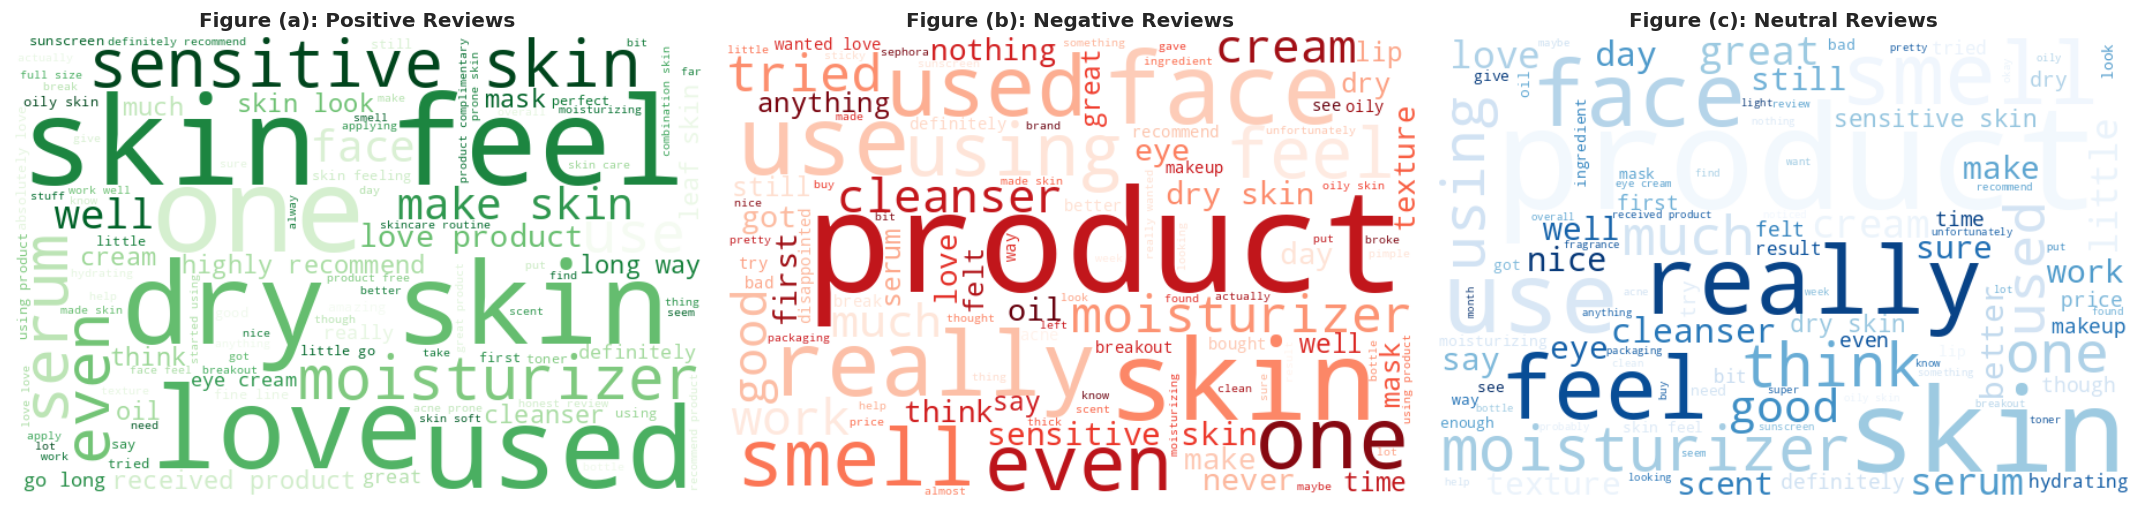

Interpretation: Positive reviews frequently mention 'love', 'skin', 'feel', 'work'. Negative reviews highlight 'dry', 'break', 'smell', 'return'.


In [24]:
# FIGURE — Word Clouds: Positive, Negative, Neutral Reviews

def get_words_by_sentiment(df, sentiment):
    texts = df[df['sentiment_label'] == sentiment]['normal_text'].str.cat(sep=' ')
    return texts

pos_text = get_words_by_sentiment(sample_nlp, 'Positive')
neg_text = get_words_by_sentiment(sample_nlp, 'Negative')
neu_text = get_words_by_sentiment(sample_nlp, 'Neutral')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap_list = ['Greens', 'Reds', 'Blues']
texts_list = [pos_text, neg_text, neu_text]
titles = ['Figure (a): Positive Reviews', 'Figure (b): Negative Reviews', 'Figure (c): Neutral Reviews']

for ax, text, cmap, title in zip(axes, texts_list, cmap_list, titles):
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_wordclouds.png', bbox_inches='tight')
plt.show()
print("Interpretation: Positive reviews frequently mention 'love', 'skin', 'feel', 'work'."
      " Negative reviews highlight 'dry', 'break', 'smell', 'return'.")

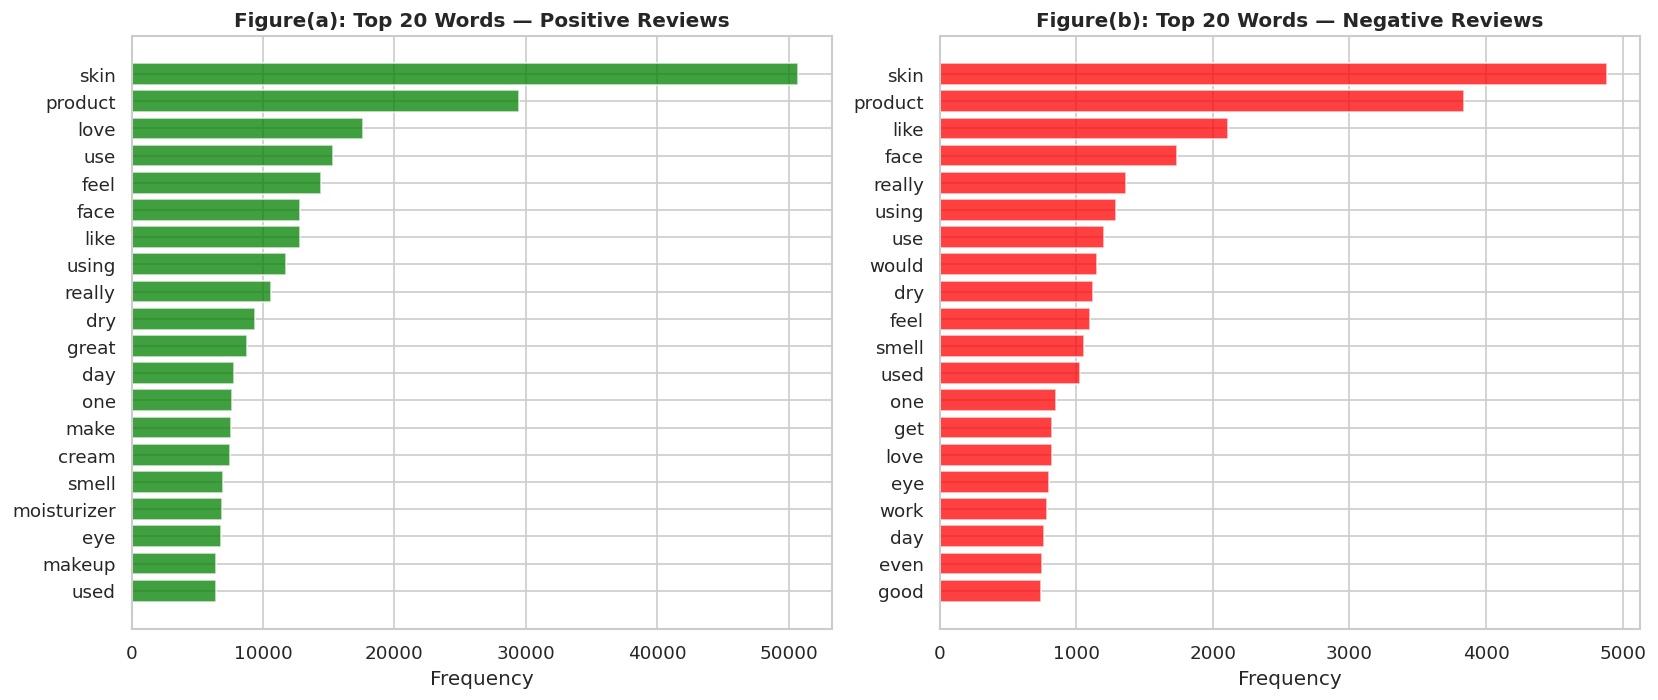

In [25]:
# FIGURE — Top-20 Word Frequency Comparison

def top_n_words(text, n=20):
    words = text.split()
    return Counter(words).most_common(n)

pos_top = top_n_words(pos_text)
neg_top = top_n_words(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

words_p, counts_p = zip(*pos_top)
axes[0].barh(words_p, counts_p, color='green', alpha=0.75)
axes[0].invert_yaxis()
axes[0].set_title('Figure(a): Top 20 Words — Positive Reviews', fontweight='bold')
axes[0].set_xlabel('Frequency')

words_n, counts_n = zip(*neg_top)
axes[1].barh(words_n, counts_n, color='red', alpha=0.75)
axes[1].invert_yaxis()
axes[1].set_title('Figure(b): Top 20 Words — Negative Reviews', fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('fig8_2_word_frequency.png', bbox_inches='tight')
plt.show()

In [26]:
# SECTION — LDA Topic Modeling

# Vectorize text (bag-of-words)
cv = CountVectorizer(max_features=3000, min_df=5, max_df=0.9)
doc_term_matrix = cv.fit_transform(sample_nlp['normal_text'])

# LDA model
n_topics = 5
lda_model = LatentDirichletAllocation(
    n_components=n_topics, max_iter=15,
    learning_method='online', random_state=42
)
lda_model.fit(doc_term_matrix)

# Display topics
feature_names = cv.get_feature_names_out()

print("TABLE: LDA Topic Modeling Results — Top 15 Words per Topic")
print("=" * 65)

topic_labels = [
    'Topic 1: Moisturization & Hydration',
    'Topic 2: Fragrance & Texture',
    'Topic 3: Skin Concerns & Breakouts',
    'Topic 4: Product Efficacy & Routine',
    'Topic 5: Packaging & Value'
]

for idx, (topic, label) in enumerate(zip(lda_model.components_, topic_labels)):
    top_words = [feature_names[i] for i in topic.argsort()[:-16:-1]]
    print(f"\n{label}")
    print(f"  Keywords: {', '.join(top_words)}")

print("\nInterpretation: LDA identifies 5 distinct latent themes in consumer reviews,"
      " ranging from product efficacy to packaging concerns.")

TABLE: LDA Topic Modeling Results — Top 15 Words per Topic

Topic 1: Moisturization & Hydration
  Keywords: skin, product, love, feel, moisturizer, like, great, really, dry, received, make, cream, smell, soft, smooth

Topic 2: Fragrance & Texture
  Keywords: like, product, lip, one, smell, use, price, get, little, balm, love, good, day, much, time

Topic 3: Skin Concerns & Breakouts
  Keywords: face, makeup, cleanser, use, like, product, size, clean, sunscreen, sample, wash, really, full, feel, got

Topic 4: Product Efficacy & Routine
  Keywords: eye, product, using, serum, cream, difference, see, week, result, line, noticed, skin, use, dark, look

Topic 5: Packaging & Value
  Keywords: skin, product, acne, using, dry, use, sensitive, face, day, used, pore, breakout, week, oily, time

Interpretation: LDA identifies 5 distinct latent themes in consumer reviews, ranging from product efficacy to packaging concerns.


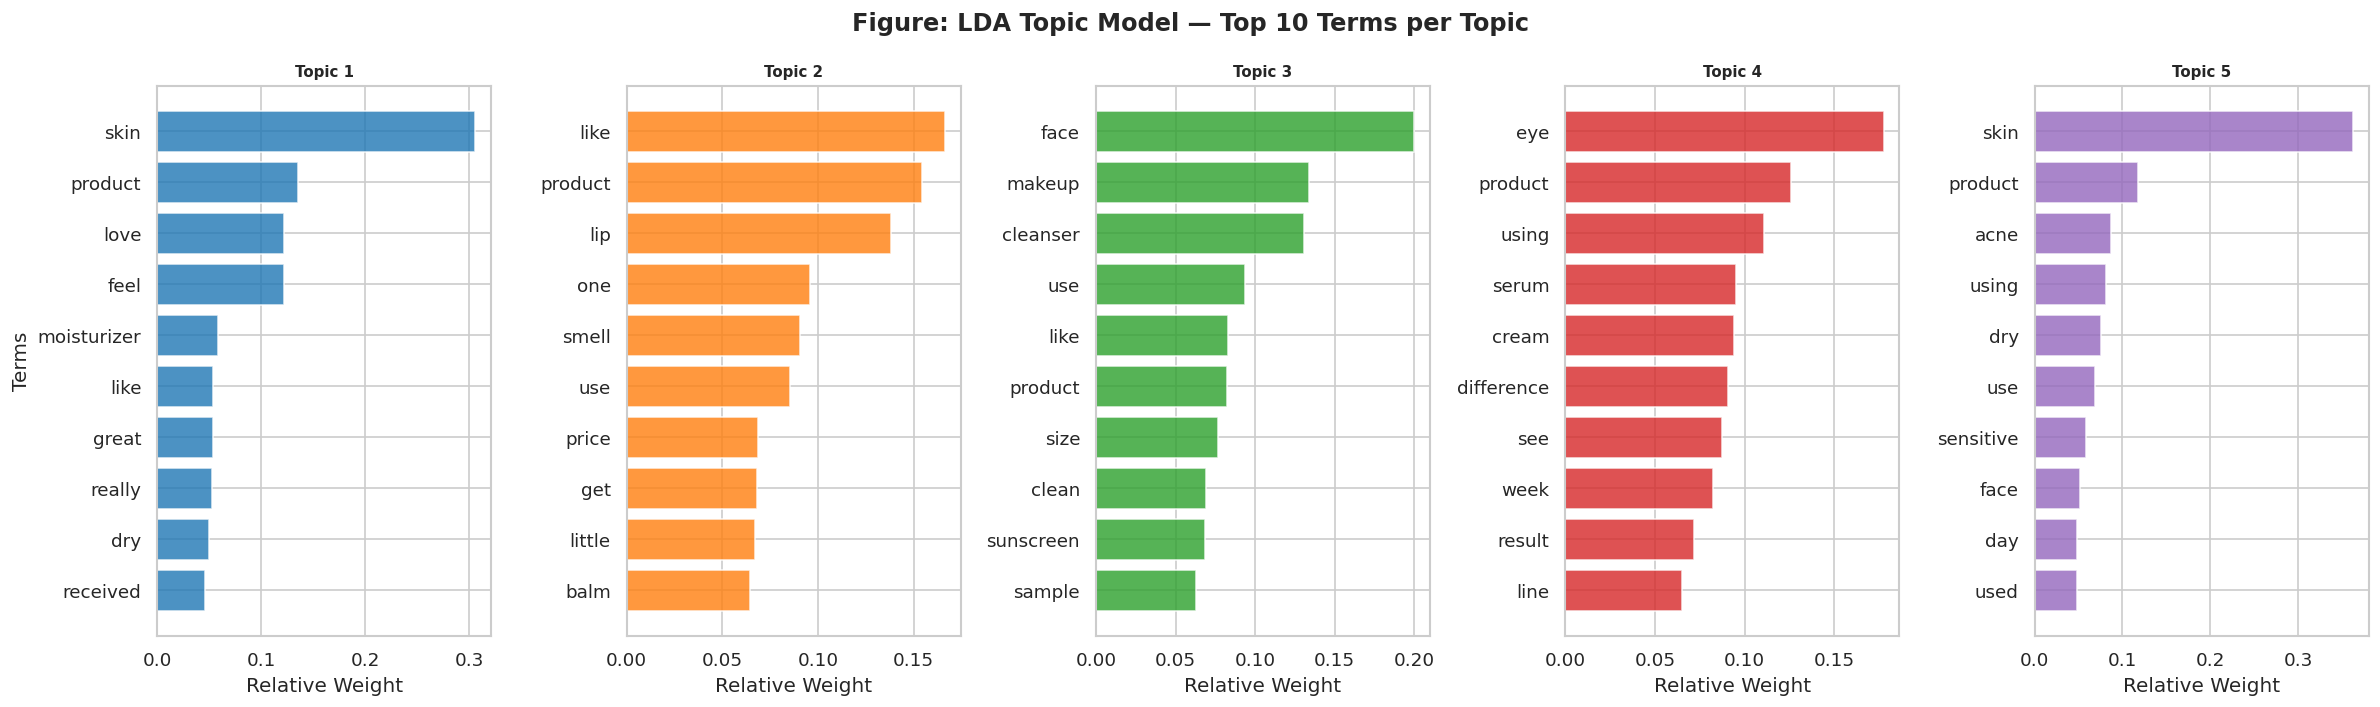

In [27]:
# FIGURE — LDA Topic Word Distribution (Horizontal Bar)

fig, axes = plt.subplots(1, n_topics, figsize=(20, 6), sharey=False)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, (topic, label, color) in enumerate(
        zip(lda_model.components_, topic_labels, colors)):
    top_idx = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_idx]
    top_weights = topic[top_idx] / topic[top_idx].sum()

    axes[idx].barh(top_words, top_weights, color=color, alpha=0.8)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Topic {idx+1}', fontweight='bold', fontsize=9)
    axes[idx].set_xlabel('Relative Weight')
    if idx == 0:
        axes[idx].set_ylabel('Terms')

plt.suptitle('Figure: LDA Topic Model — Top 10 Terms per Topic', fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_3_lda_topics.png', bbox_inches='tight')
plt.show()

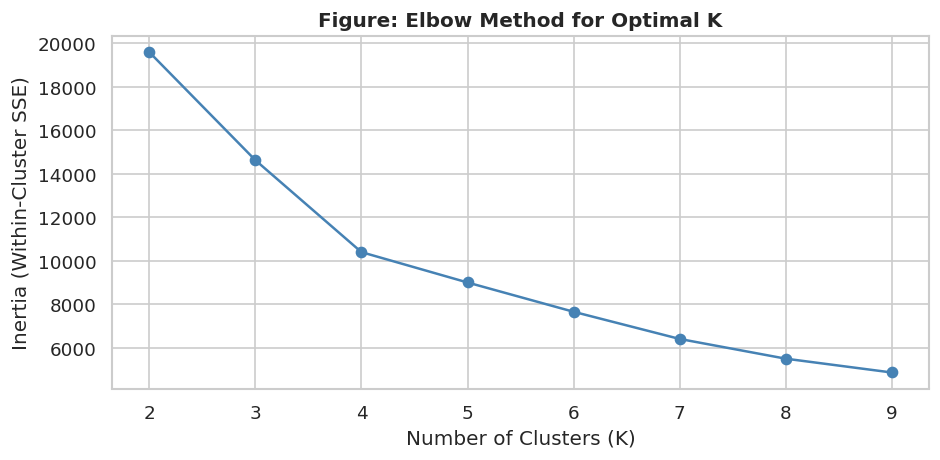

TABLE: Cluster Profile Summary
         rating  price_usd  loves_count     n
cluster                                      
0          3.46      40.70     17220.46  1864
1          4.42      55.12     21815.86  6095
2          4.28      35.19    321286.80   257

Note: Clusters correspond to distinct product segments (budget/mid/premium).


In [28]:
# SECTION — K-Means Clustering

cluster_features = ['rating', 'price_usd', 'loves_count']
df_cluster = df_product[cluster_features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Elbow Method
inertia = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertia, marker='o', color='steelblue')
ax.set_title('Figure: Elbow Method for Optimal K', fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster SSE)')
plt.tight_layout()
plt.savefig('fig8_4_elbow.png', bbox_inches='tight')
plt.show()

# Fit final model with K=3
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_cluster = df_cluster.copy()
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

print("TABLE: Cluster Profile Summary")
cluster_summary = df_cluster.groupby('cluster')[cluster_features].mean().round(2)
cluster_summary['n'] = df_cluster.groupby('cluster').size()
cluster_labels_map = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}
print(cluster_summary.to_string())
print("\nNote: Clusters correspond to distinct product segments (budget/mid/premium).")

PCA Explained Variance:
  PC1: 36.34%
  PC2: 34.56%
  Total: 70.89%


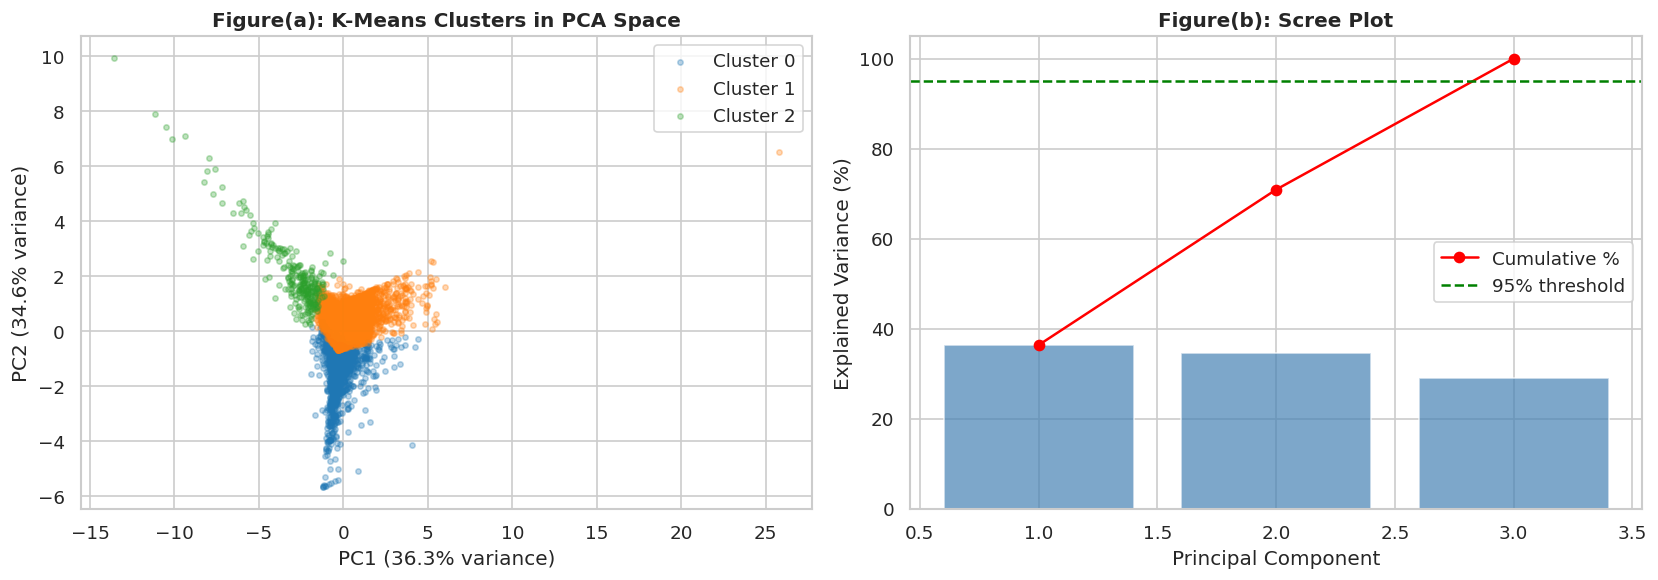

In [29]:
# SECTION — PCA and Cluster Visualization

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print(f"PCA Explained Variance:")
print(f"  PC1: {explained_var[0]*100:.2f}%")
print(f"  PC2: {explained_var[1]*100:.2f}%")
print(f"  Total: {sum(explained_var)*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
colors_cluster = ['#1f77b4', '#ff7f0e', '#2ca02c']
for c in range(K_FINAL):
    mask = df_cluster['cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    alpha=0.3, s=10, label=f'Cluster {c}',
                    color=colors_cluster[c])
axes[0].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
axes[0].set_title('Figure(a): K-Means Clusters in PCA Space', fontweight='bold')
axes[0].legend()

# Scree plot
pca_full = PCA().fit(X_scaled)
axes[1].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_ * 100,
            color='steelblue', alpha=0.7)
axes[1].plot(range(1, len(pca_full.explained_variance_ratio_)+1),
             np.cumsum(pca_full.explained_variance_ratio_) * 100,
             marker='o', color='red', label='Cumulative %')
axes[1].axhline(95, color='green', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance (%)')
axes[1].set_title('Figure(b): Scree Plot', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig8_5_pca.png', bbox_inches='tight')
plt.show()

In [30]:
# SECTION — Skincare Recommendation Function
# (Statistical Filtering: Skin Type + Budget)

def recommend_products(skin_type: str, budget: float, top_n: int = 5):
    """
    Recommend top-N products filtered by reviewer skin type and price budget.
    Ranked by: (i) average rating, (ii) loves_count.
    """
    filtered = df_merged[
        (df_merged['skin_type'].str.lower().str.strip() == skin_type.lower()) &
        (df_merged['price_usd'] <= budget)
    ].copy()

    if filtered.empty:
        return f"No products found for skin type='{skin_type}' within budget=${budget}."

    result = (
        filtered
        .groupby(['product_name', 'brand_name', 'price_usd', 'primary_category'])
        .agg(avg_rating=('rating', 'mean'),
             review_count=('rating', 'count'),
             loves_count=('loves_count', 'max'),
             rec_rate=('is_recommended', 'mean'))
        .reset_index()
        .sort_values(['avg_rating', 'loves_count'], ascending=False)
        .head(top_n)
    )

    result['avg_rating'] = result['avg_rating'].round(2)
    result['rec_rate'] = (result['rec_rate'] * 100).round(1).astype(str) + '%'
    return result

# Example invocations
print("Recommendations for OILY skin, Budget $50:")
print(recommend_products('oily', 50).to_string(index=False))

print("\nRecommendations for DRY skin, Budget $80:")
print(recommend_products('dry', 80).to_string(index=False))

print("\nRecommendations for Combination skin, Budget $50:")
print(recommend_products('combination', 50).to_string(index=False))

Recommendations for OILY skin, Budget $50:
                                                    product_name     brand_name  price_usd primary_category  avg_rating  review_count  loves_count rec_rate
                          Dermask Water Jet Vital Hydra Solution      Dr. Jart+        7.0         Skincare         5.0            17        40090   100.0%
                   Day Dream Vitamin C + Hydration Serum Duo 2.0 Drunk Elephant       26.0         Skincare         5.0             1        39446   100.0%
Midnight Secret Late Night Recovery Treatment Anti-Fatigue Serum       GUERLAIN       32.0         Skincare         5.0             3        26130   100.0%
     BTS |  Amorepacific Lip Sleeping Mask Lip & Pop Edition Set        LANEIGE       35.0         Skincare         5.0             4        23044   100.0%
                                             The Skinimalist Set   The Ordinary       22.0         Skincare         5.0             1        23001   100.0%

Recommendations for 